## Setup and Imports

In [2]:
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,roc_curve
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from transformers import AutoTokenizer,AutoModel
import warnings

In [3]:
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
# if torch.cuda.is_available():
#     print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda


## Configuration

In [5]:
class Config:
    DATA_DIR="../data"
    IMAGE_DIR=os.path.join(DATA_DIR,"images","images")
    REPORTS_CSV=os.path.join(DATA_DIR,"indiana_reports.csv")
    PROJECTIONS_CSV=os.path.join(DATA_DIR,"indiana_projections.csv")
    
    IMAGE_SIZE=224
    BATCH_SIZE=8
    MAX_SEQ_LEN=128
    NUM_CLASSES=5
    LR=1e-4
    EPOCHS=10
    D_MODEL=256
    NHEAD=8
    NUM_DECODER_LAYERS=3
    
    DISEASES=["pneumonia","cardiomegaly","effusion","atelectasis","edema"]
    
    VAL_SPLIT=0.1
    RANDOM_SEED=42
    GRADIENT_CLIP=1.0
    WEIGHT_DECAY=0.01
    
    MAX_GEN_LEN=100

In [6]:
config=Config()
print("Configuration loaded:")
print(f"Image size: {config.IMAGE_SIZE}")
print(f"Batch size: {config.BATCH_SIZE}")
print(f"Max sequence length: {config.MAX_SEQ_LEN}")
print(f"Number of diseases: {config.NUM_CLASSES}")
print(f"Diseases: {config.DISEASES}")

Configuration loaded:
Image size: 224
Batch size: 8
Max sequence length: 128
Number of diseases: 5
Diseases: ['pneumonia', 'cardiomegaly', 'effusion', 'atelectasis', 'edema']


## Load and Explore Data

In [7]:
reports=pd.read_csv(config.REPORTS_CSV)
projections=pd.read_csv(config.PROJECTIONS_CSV)

print("Reports shape:",reports.shape)
print("Projections shape:",projections.shape)
print("\nReports columns:",reports.columns.tolist())
print("Projections columns:",projections.columns.tolist())

df=projections.merge(reports,on="uid")
print(f"\nTotal samples after merge: {len(df)}")

print("\nSample data:")
df.head()

Reports shape: (3851, 8)
Projections shape: (7466, 3)

Reports columns: ['uid', 'MeSH', 'Problems', 'image', 'indication', 'comparison', 'findings', 'impression']
Projections columns: ['uid', 'filename', 'projection']

Total samples after merge: 7466

Sample data:


,uid,filename,projection,MeSH,Problems,image,indication,comparison,findings,impression
0,1,CXR1_IM-0001-4001.png,Frontal,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
1,1,CXR1_IM-0001-3001.png,Lateral,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
2,2,CXR2_IM-0652-1001.png,Frontal,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
3,2,CXR2_IM-0652-2001.png,Lateral,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
4,3,CXR3_IM-1384-1001.png,Frontal,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p..."


## Data Cleaning and Preprocessing

In [8]:
def clean_text(row):
    findings=str(row["findings"]) if pd.notna(row["findings"]) and str(row["findings"])!="nan" else ""
    impression=str(row["impression"]) if pd.notna(row["impression"]) and str(row["impression"])!="nan" else ""
    
    if impression and impression.lower()!="none":
        text=impression
    elif findings and findings.lower()!="none":
        text=findings
    else:
        text=""
    
    text=text.lower().strip()
    text=" ".join(text.split())
    text=text.replace("xxxx","")
    
    return text

In [9]:
def create_labels(text,diseases):
    labels=[]
    for disease in diseases:
        if disease in text:
            labels.append(1)
        else:
            synonyms={
                "cardiomegaly": ["enlarged heart","cardiac enlargement","enlarged cardiac"],
                "effusion": ["pleural effusion","fluid"],
                "atelectasis": ["collapse","lung collapse"],
                "edema": ["pulmonary edema","fluid overload"]
            }
            
            found=False
            if disease in synonyms:
                for syn in synonyms[disease]:
                    if syn in text:
                        found = True
                        break
            
            labels.append(1 if found else 0)
    
    return labels

In [10]:
df["report"]=df.apply(clean_text, axis=1)

df=df[df["report"]!=""].reset_index(drop=True)
print(f"Samples after cleaning: {len(df)}")

df["labels"]=df["report"].apply(lambda x: create_labels(x,config.DISEASES))

print("\nCleaned data sample:")
df[["filename","projection","report","labels"]].head()

Samples after cleaning: 7426

Cleaned data sample:


,filename,projection,report,labels
0,CXR1_IM-0001-4001.png,Frontal,normal chest x-.,"[0, 0, 0, 0, 0]"
1,CXR1_IM-0001-3001.png,Lateral,normal chest x-.,"[0, 0, 0, 0, 0]"
2,CXR2_IM-0652-1001.png,Frontal,no acute pulmonary findings.,"[0, 0, 0, 0, 0]"
3,CXR2_IM-0652-2001.png,Lateral,no acute pulmonary findings.,"[0, 0, 0, 0, 0]"
4,CXR3_IM-1384-1001.png,Frontal,"no displaced rib fractures, pneumothorax, or p...","[0, 0, 1, 0, 0]"


## Data Statistics and Visualization

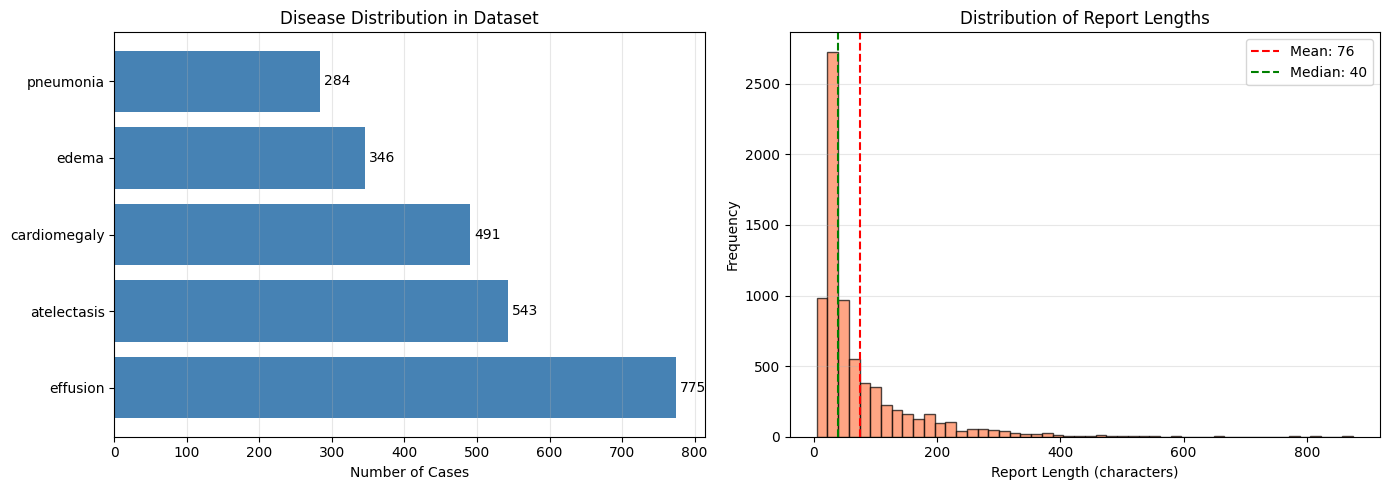

Average report length: 75.83 characters
Max report length: 875 characters
Min report length: 5 characters


In [11]:
for i,disease in enumerate(config.DISEASES):
    df[disease]=df["labels"].apply(lambda x: x[i])

disease_counts=df[config.DISEASES].sum().sort_values(ascending=False)

fig,axes=plt.subplots(1,2,figsize=(14,5))

axes[0].barh(disease_counts.index,disease_counts.values,color='steelblue')
axes[0].set_xlabel('Number of Cases')
axes[0].set_title('Disease Distribution in Dataset')
axes[0].grid(axis='x',alpha=0.3)

for i,v in enumerate(disease_counts.values):
    axes[0].text(v+5,i,str(v),va='center')

report_lengths=df["report"].str.len()
axes[1].hist(report_lengths,bins=50,color='coral',edgecolor='black',alpha=0.7)
axes[1].set_xlabel('Report Length (characters)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Report Lengths')
axes[1].axvline(report_lengths.mean(),color='red',linestyle='--',label=f'Mean: {report_lengths.mean():.0f}')
axes[1].axvline(report_lengths.median(),color='green',linestyle='--',label=f'Median: {report_lengths.median():.0f}')
axes[1].legend()
axes[1].grid(axis='y',alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average report length: {report_lengths.mean():.2f} characters")
print(f"Max report length: {report_lengths.max()} characters")
print(f"Min report length: {report_lengths.min()} characters")

## Train-Validation Split

In [12]:
train_df,val_df=train_test_split(
    df, 
    test_size=config.VAL_SPLIT, 
    random_state=config.RANDOM_SEED,
    stratify=df[config.DISEASES].sum(axis=1).values
)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Training/Validation ratio: {len(train_df)/len(val_df):.2f}")

train_counts=train_df[config.DISEASES].sum()
val_counts=val_df[config.DISEASES].sum()

comparison_df=pd.DataFrame({
    'Training': train_counts,
    'Validation': val_counts,
    'Total': disease_counts
})
print("\nDisease distribution across splits:")
print(comparison_df)

Training samples: 6683
Validation samples: 743
Training/Validation ratio: 8.99

Disease distribution across splits:
              Training  Validation  Total
atelectasis        480          63    543
cardiomegaly       443          48    491
edema              312          34    346
effusion           707          68    775
pneumonia          255          29    284


## Tokenizer Setup

In [13]:
tokenizer=AutoTokenizer.from_pretrained("bert-base-uncased")
vocab_size=tokenizer.vocab_size
pad_token_id=tokenizer.pad_token_id

print(f"Tokenizer vocabulary size: {vocab_size}")
print(f"Pad token ID: {pad_token_id}")
print(f"CLS token: {tokenizer.cls_token} (ID: {tokenizer.cls_token_id})")
print(f"SEP token: {tokenizer.sep_token} (ID: {tokenizer.sep_token_id})")

sample_text=train_df["report"].iloc[0]
tokens=tokenizer(sample_text,padding="max_length",truncation=True,max_length=config.MAX_SEQ_LEN)
print(f"\nSample text: {sample_text[:100]}...")
print(f"Tokenized length: {len(tokens['input_ids'])}")

Tokenizer vocabulary size: 30522
Pad token ID: 0
CLS token: [CLS] (ID: 101)
SEP token: [SEP] (ID: 102)

Sample text: no acute pulmonary disease....
Tokenized length: 128


## Dataset Class

In [14]:
class ChestXRayDataset(Dataset):
    def __init__(self,df,image_dir,tokenizer,transform,max_seq_len=128):
        self.df=df
        self.image_dir=image_dir
        self.tokenizer=tokenizer
        self.transform=transform
        self.max_seq_len=max_seq_len
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self,idx):
        row=self.df.iloc[idx]
        
        img_path=os.path.join(self.image_dir,row["filename"])
        
        if not os.path.exists(img_path):
            img_path = os.path.join(self.image_dir,row["image"]) if "image" in row else None
            if not img_path or not os.path.exists(img_path):
                print(f"Warning: Image not found: {img_path}")
                return self.__getitem__((idx + 1)%len(self.df))
        
        try:
            img=Image.open(img_path).convert("RGB")
            img=self.transform(img)
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            return self.__getitem__((idx + 1)%len(self.df))
        
        labels=torch.tensor(row["labels"],dtype=torch.float32)
        
        tokens=self.tokenizer(
            row["report"],
            padding="max_length",
            truncation=True,
            max_length=self.max_seq_len,
            return_tensors="pt"
        )
        
        return {
            "image": img,
            "labels": labels,
            "input_ids": tokens["input_ids"].squeeze(0),
            "attention_mask": tokens["attention_mask"].squeeze(0),
            "report": row["report"],
            "filename": row["filename"]
        }

In [15]:
train_transform=transforms.Compose([
    transforms.Resize((config.IMAGE_SIZE,config.IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2,contrast=0.2,saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])

val_transform=transforms.Compose([
    transforms.Resize((config.IMAGE_SIZE,config.IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])

train_dataset=ChestXRayDataset(train_df,config.IMAGE_DIR,tokenizer,train_transform,config.MAX_SEQ_LEN)
val_dataset=ChestXRayDataset(val_df,config.IMAGE_DIR,tokenizer,val_transform,config.MAX_SEQ_LEN)

train_loader=DataLoader(
    train_dataset, 
    batch_size=config.BATCH_SIZE, 
    shuffle=True, 
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader=DataLoader(
    val_dataset, 
    batch_size=config.BATCH_SIZE, 
    shuffle=False, 
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

In [16]:
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training batches: 836
Validation batches: 93


## Visualize Sample Data

Training samples:


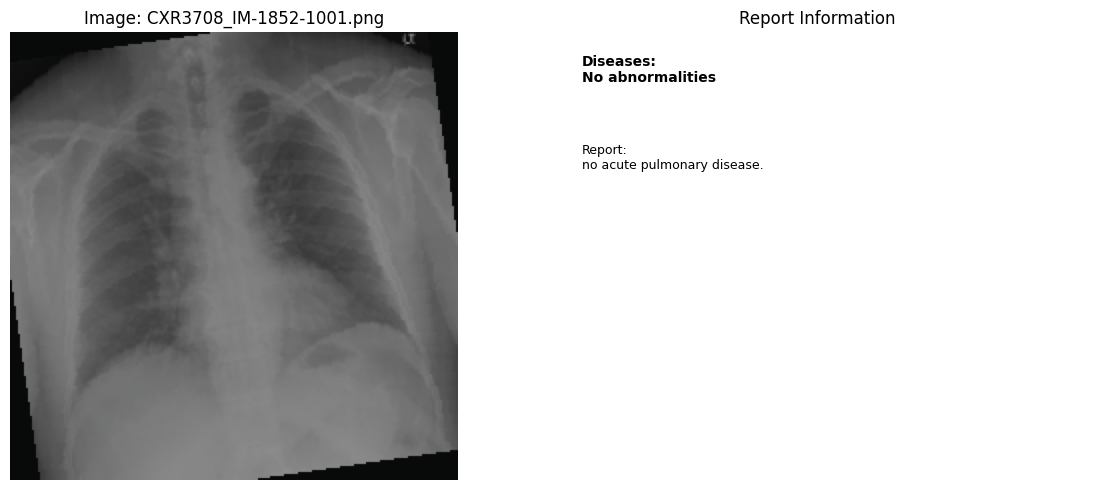

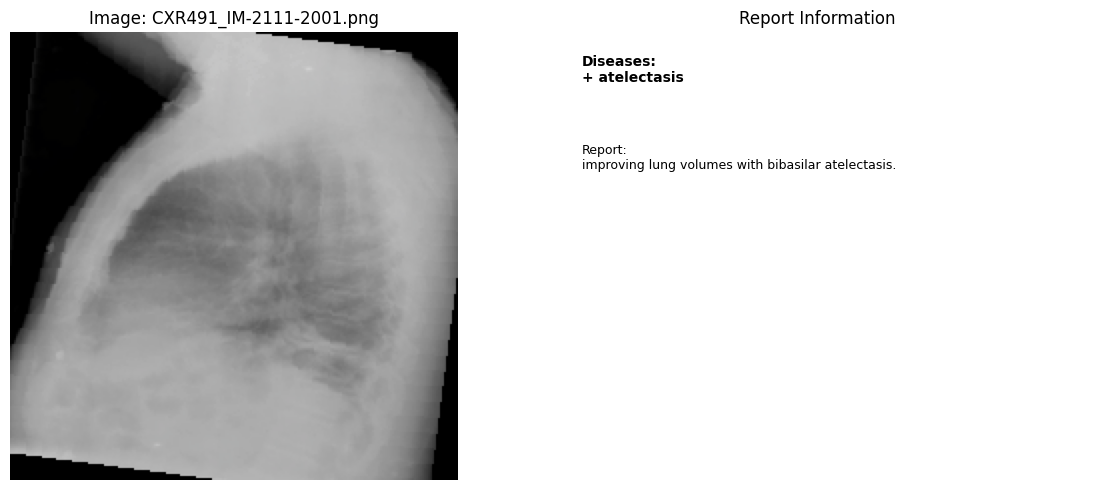

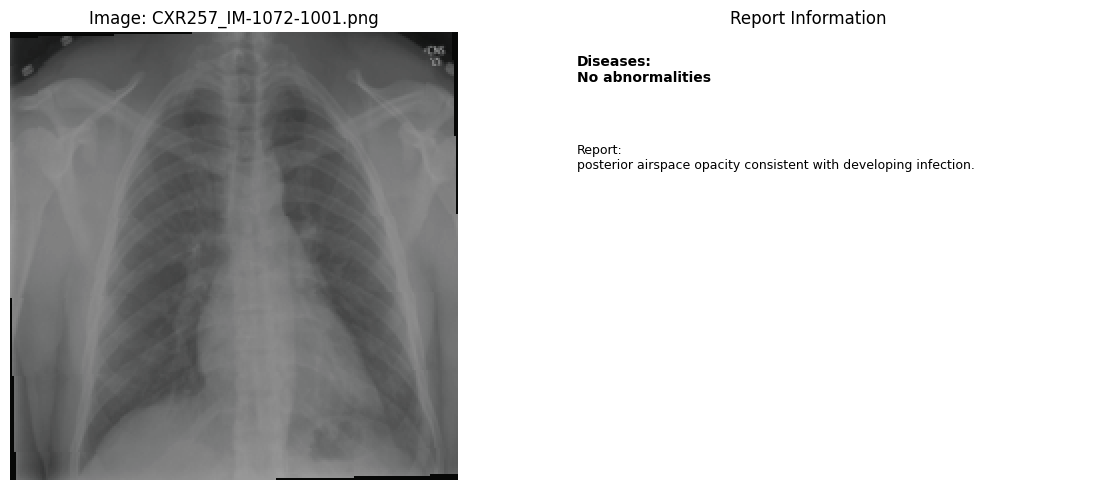


Validation samples:


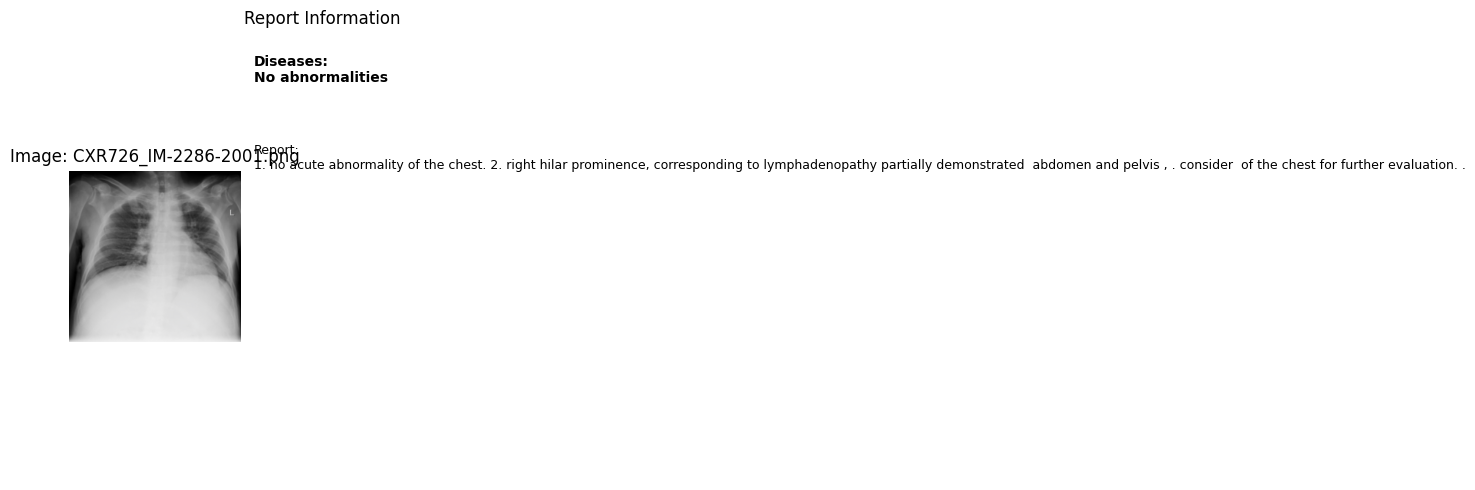

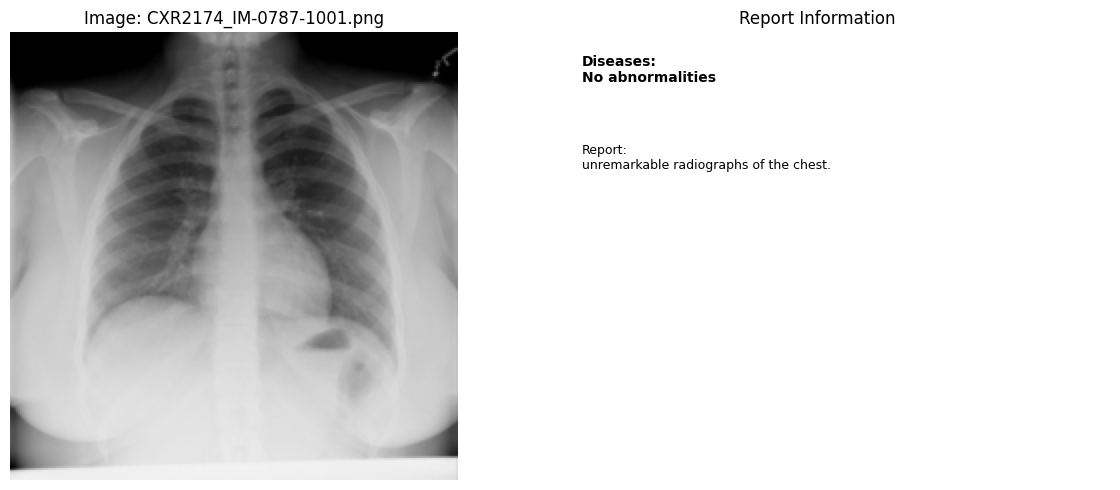

In [17]:
def display_sample(dataset,idx):
    sample=dataset[idx]
    
    fig,axes=plt.subplots(1,2,figsize=(12,5))
    
    img=sample["image"].permute(1,2,0).numpy()

    mean=np.array([0.485,0.456,0.406])
    std=np.array([0.229,0.224,0.225])
    img=img*std+mean
    img=np.clip(img,0,1)
    
    axes[0].imshow(img)
    axes[0].set_title(f"Image: {sample['filename']}")
    axes[0].axis('off')
    
    labels_text="Diseases:\n"
    for i, disease in enumerate(config.DISEASES):
        if sample["labels"][i]==1:
            labels_text+=f"+ {disease}\n"
    if labels_text=="Diseases:\n":
        labels_text+="No abnormalities"
    
    report_text=sample["report"]
    if len(report_text)>200:
        report_text=report_text[:200]+"..."
    
    axes[1].text(0.1,0.95,labels_text,transform=axes[1].transAxes,fontsize=10,verticalalignment='top',fontweight='bold')
    axes[1].text(0.1,0.75,f"Report:\n{report_text}",transform=axes[1].transAxes,fontsize=9,verticalalignment='top')
    axes[1].axis('off')
    axes[1].set_title("Report Information")
    
    plt.tight_layout()
    plt.show()

print("Training samples:")
for i in range(3):
    display_sample(train_dataset,i)

print("\nValidation samples:")
for i in range(2):
    display_sample(val_dataset,i)

## Model Architecture

In [18]:
class MBConv(nn.Module):
    def __init__(self,in_ch,out_ch,expand=6,stride=1,dropout=0.1):
        super().__init__()
        hidden_dim=in_ch*expand
        self.use_res=stride==1 and in_ch==out_ch
        
        layers=[]
        
        if expand>1:
            layers.extend([
                nn.Conv2d(in_ch,hidden_dim,1,bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.SiLU()
            ])
        
        conv_in=hidden_dim if expand>1 else in_ch
        layers.extend([
            nn.Conv2d(conv_in,conv_in,3,stride,1,groups=conv_in,bias=False),
            nn.BatchNorm2d(conv_in),
            nn.SiLU()
        ])
        
        layers.extend([
            nn.Conv2d(conv_in,out_ch,1,bias=False),
            nn.BatchNorm2d(out_ch),
            nn.Dropout2d(dropout) if dropout>0 else nn.Identity()
        ])
        
        self.conv=nn.Sequential(*layers)
        
    def forward(self,x):
        if self.use_res:
            return x+self.conv(x)
        return self.conv(x)

In [19]:
class EfficientNetEncoder(nn.Module):
    def __init__(self,dropout=0.2):
        super().__init__()
        
        self.stem=nn.Sequential(
            nn.Conv2d(3,32,3,stride=2,padding=1,bias=False),
            nn.BatchNorm2d(32),
            nn.SiLU()
        )
        
        blocks_config=[
            (32,16,1,1,1),
            (16,24,6,2,2),
            (24,40,6,2,2),
            (40,80,6,2,3),
            (80,112,6,1,3),
            (112,192,6,2,4),
            (192,320,6,1,1),
        ]
        
        layers=[]
        for in_ch,out_ch,expand,stride,repeats in blocks_config:
            for i in range(repeats):
                layers.append(MBConv(
                    in_ch if i==0 else out_ch,
                    out_ch,
                    expand,
                    stride if i==0 else 1,
                    dropout=0.1
                ))
        
        self.blocks=nn.Sequential(*layers)
        self.pool=nn.AdaptiveAvgPool2d(1)
        self.out_channels=320
        self.dropout=nn.Dropout(dropout)
        
    def forward(self, x):
        x=self.stem(x)
        x=self.blocks(x)
        x=self.pool(x)
        x=x.view(x.size(0),-1)
        x=self.dropout(x)
        return x

In [20]:
class ReportGenerator(nn.Module):
    def __init__(self,feature_dim,vocab_size,d_model=256,nhead=8,num_layers=3):
        super().__init__()
        
        self.embed=nn.Embedding(vocab_size,d_model)
        self.pos_encoder=nn.Embedding(512,d_model)
        
        decoder_layer=nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=1024,
            dropout=0.1,
            activation='gelu',
            batch_first=False
        )
        self.decoder=nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        
        self.fc_out=nn.Linear(d_model,vocab_size)
        self.feature_proj=nn.Linear(feature_dim,d_model)
        self.dropout=nn.Dropout(0.1)
        
    def forward(self,features,input_ids,attention_mask=None):
        batch_size,seq_len=input_ids.shape
        
        positions=torch.arange(seq_len,device=input_ids.device).unsqueeze(0).expand(batch_size,-1)
        
        tgt=self.embed(input_ids)+self.pos_encoder(positions)
        tgt=self.dropout(tgt)
        
        memory=self.feature_proj(features).unsqueeze(0)
        
        causal_mask=torch.triu(torch.ones(seq_len,seq_len,device=input_ids.device)*float('-inf'),diagonal=1)
        
        out=self.decoder(
            tgt.permute(1,0,2),
            memory,
            tgt_mask=causal_mask,
            tgt_key_padding_mask=~attention_mask.bool() if attention_mask is not None else None
        )
        
        out=out.permute(1,0,2)
        out=self.fc_out(out)
        
        return out

In [21]:
class FullModel(nn.Module):
    def __init__(self,num_classes,vocab_size):
        super().__init__()
        self.encoder=EfficientNetEncoder()
        self.classifier=nn.Sequential(
            nn.Linear(320,128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128,num_classes)
        )
        self.report_generator=ReportGenerator(320, vocab_size)
        
    def forward(self,images,input_ids,attention_mask=None):
        features=self.encoder(images)
        cls_out=self.classifier(features)
        report_out=self.report_generator(features,input_ids,attention_mask)
        return cls_out,report_out

In [22]:
model=FullModel(config.NUM_CLASSES,vocab_size).to(device)

total_params=sum(p.numel() for p in model.parameters())
trainable_params=sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model architecture:")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: {total_params*4/(1024**2):.2f} MB (float32)")

Model architecture:
Total parameters: 21,930,559
Trainable parameters: 21,930,559
Model size: 83.66 MB (float32)


## Training Setup

In [23]:
cls_loss_fn=nn.BCEWithLogitsLoss()
gen_loss_fn=nn.CrossEntropyLoss(ignore_index=pad_token_id)

optimizer=torch.optim.AdamW(
    model.parameters(),
    lr=config.LR,
    weight_decay=config.WEIGHT_DECAY,
    betas=(0.9,0.999)
)

scheduler=torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, 
    T_0=config.EPOCHS//3, 
    T_mult=2,
    eta_min=1e-6
)

print("Training configuration:")
print(f"Learning rate: {config.LR}")
print(f"Weight decay: {config.WEIGHT_DECAY}")
print(f"Gradient clipping: {config.GRADIENT_CLIP}")
print(f"Scheduler: CosineAnnealingWarmRestarts")

Training configuration:
Learning rate: 0.0001
Weight decay: 0.01
Gradient clipping: 1.0
Scheduler: CosineAnnealingWarmRestarts


## Training Function

In [24]:
def train_epoch(model,dataloader,optimizer,cls_loss_fn,gen_loss_fn,epoch,config):
    model.train()
    total_loss=0
    total_cls_loss=0
    total_gen_loss=0
    all_preds=[]
    all_labels=[]
    
    for batch_idx,batch in enumerate(dataloader):
        images=batch["image"].to(device)
        labels=batch["labels"].to(device)
        input_ids=batch["input_ids"].to(device)
        attention_mask=batch["attention_mask"].to(device)
        
        optimizer.zero_grad()
        
        cls_out,report_out=model(images,input_ids,attention_mask)
        
        cls_loss=cls_loss_fn(cls_out,labels)
        
        report_out=report_out[:,:-1,:]
        target_ids=input_ids[:,1:]
        
        gen_loss=gen_loss_fn(
            report_out.reshape(-1,vocab_size),
            target_ids.reshape(-1)
        )
        
        loss=cls_loss+gen_loss
        
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=config.GRADIENT_CLIP)
        
        optimizer.step()
        
        total_loss+=loss.item()
        total_cls_loss+=cls_loss.item()
        total_gen_loss+=gen_loss.item()
        
        preds=torch.sigmoid(cls_out).cpu().detach().numpy()>0.5
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().detach().numpy())
        
        if batch_idx%50==0:
            print(f"Epoch {epoch+1}/{config.EPOCHS} | Batch {batch_idx}/{len(dataloader)} | "
                  f"Loss: {loss.item():.4f} | Cls: {cls_loss.item():.4f} | Gen: {gen_loss.item():.4f}")
    
    avg_loss=total_loss/len(dataloader)
    avg_cls_loss=total_cls_loss/len(dataloader)
    avg_gen_loss=total_gen_loss/len(dataloader)
    
    return avg_loss,avg_cls_loss,avg_gen_loss,np.array(all_preds),np.array(all_labels)

In [25]:
def validate_epoch(model,dataloader,cls_loss_fn,gen_loss_fn,config):
    model.eval()
    total_loss=0
    total_cls_loss=0
    total_gen_loss=0
    all_preds=[]
    all_labels=[]
    
    with torch.no_grad():
        for batch in dataloader:
            images=batch["image"].to(device)
            labels=batch["labels"].to(device)
            input_ids=batch["input_ids"].to(device)
            attention_mask=batch["attention_mask"].to(device)
            
            cls_out,report_out=model(images,input_ids,attention_mask)
            
            cls_loss=cls_loss_fn(cls_out,labels)
            
            report_out=report_out[:,:-1,:]
            target_ids=input_ids[:,1:]
            gen_loss=gen_loss_fn(
                report_out.reshape(-1,vocab_size),
                target_ids.reshape(-1)
            )
            
            loss=cls_loss+gen_loss
            
            total_loss+=loss.item()
            total_cls_loss+=cls_loss.item()
            total_gen_loss+=gen_loss.item()
            
            preds=torch.sigmoid(cls_out).cpu().numpy()>0.5
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss=total_loss/len(dataloader)
    avg_cls_loss=total_cls_loss/len(dataloader)
    avg_gen_loss=total_gen_loss/len(dataloader)
    
    return avg_loss,avg_cls_loss,avg_gen_loss,np.array(all_preds),np.array(all_labels)

## Training Loop

In [26]:
train_losses=[]
val_losses=[]
train_cls_losses=[]
val_cls_losses=[]
train_gen_losses=[]
val_gen_losses=[]

print("Starting training...\n")

for epoch in range(config.EPOCHS):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{config.EPOCHS}")
    print(f"{'='*60}")
    
    train_loss,train_cls_loss,train_gen_loss,train_preds,train_labels=train_epoch(model,train_loader,optimizer,cls_loss_fn,gen_loss_fn,epoch,config)
    
    train_losses.append(train_loss)
    train_cls_losses.append(train_cls_loss)
    train_gen_losses.append(train_gen_loss)
    
    val_loss,val_cls_loss,val_gen_loss,val_preds,val_labels=validate_epoch(model,val_loader,cls_loss_fn,gen_loss_fn,config)
    
    val_losses.append(val_loss)
    val_cls_losses.append(val_cls_loss)
    val_gen_losses.append(val_gen_loss)
    
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"Train - Loss: {train_loss:.4f} | Cls: {train_cls_loss:.4f} | Gen: {train_gen_loss:.4f}")
    print(f"Val   - Loss: {val_loss:.4f} | Cls: {val_cls_loss:.4f} | Gen: {val_gen_loss:.4f}")
    print(f"Learning Rate: {current_lr:.6f}")
    
    if len(val_preds)>0:
        from sklearn.metrics import accuracy_score
        val_acc = accuracy_score(val_labels, val_preds)
        print(f"Validation Accuracy: {val_acc:.4f}")

Starting training...


Epoch 1/10
Epoch 1/10 | Batch 0/836 | Loss: 11.2181 | Cls: 0.6941 | Gen: 10.5241
Epoch 1/10 | Batch 50/836 | Loss: 7.8425 | Cls: 0.4981 | Gen: 7.3443
Epoch 1/10 | Batch 100/836 | Loss: 3.2764 | Cls: 0.3472 | Gen: 2.9292
Epoch 1/10 | Batch 150/836 | Loss: 4.8580 | Cls: 0.3833 | Gen: 4.4747
Epoch 1/10 | Batch 200/836 | Loss: 5.8743 | Cls: 0.4438 | Gen: 5.4305
Epoch 1/10 | Batch 250/836 | Loss: 5.4540 | Cls: 0.1865 | Gen: 5.2676
Epoch 1/10 | Batch 300/836 | Loss: 4.8849 | Cls: 0.3279 | Gen: 4.5570
Epoch 1/10 | Batch 350/836 | Loss: 4.5734 | Cls: 0.2820 | Gen: 4.2914
Epoch 1/10 | Batch 400/836 | Loss: 3.5506 | Cls: 0.5821 | Gen: 2.9686
Epoch 1/10 | Batch 450/836 | Loss: 3.8010 | Cls: 0.3064 | Gen: 3.4946
Epoch 1/10 | Batch 500/836 | Loss: 2.7830 | Cls: 0.1823 | Gen: 2.6007
Epoch 1/10 | Batch 550/836 | Loss: 3.0898 | Cls: 0.2407 | Gen: 2.8491
Epoch 1/10 | Batch 600/836 | Loss: 1.2482 | Cls: 0.0869 | Gen: 1.1613
Epoch 1/10 | Batch 650/836 | Loss: 2.5598 | Cls: 0.2132 |

## Training Visualization

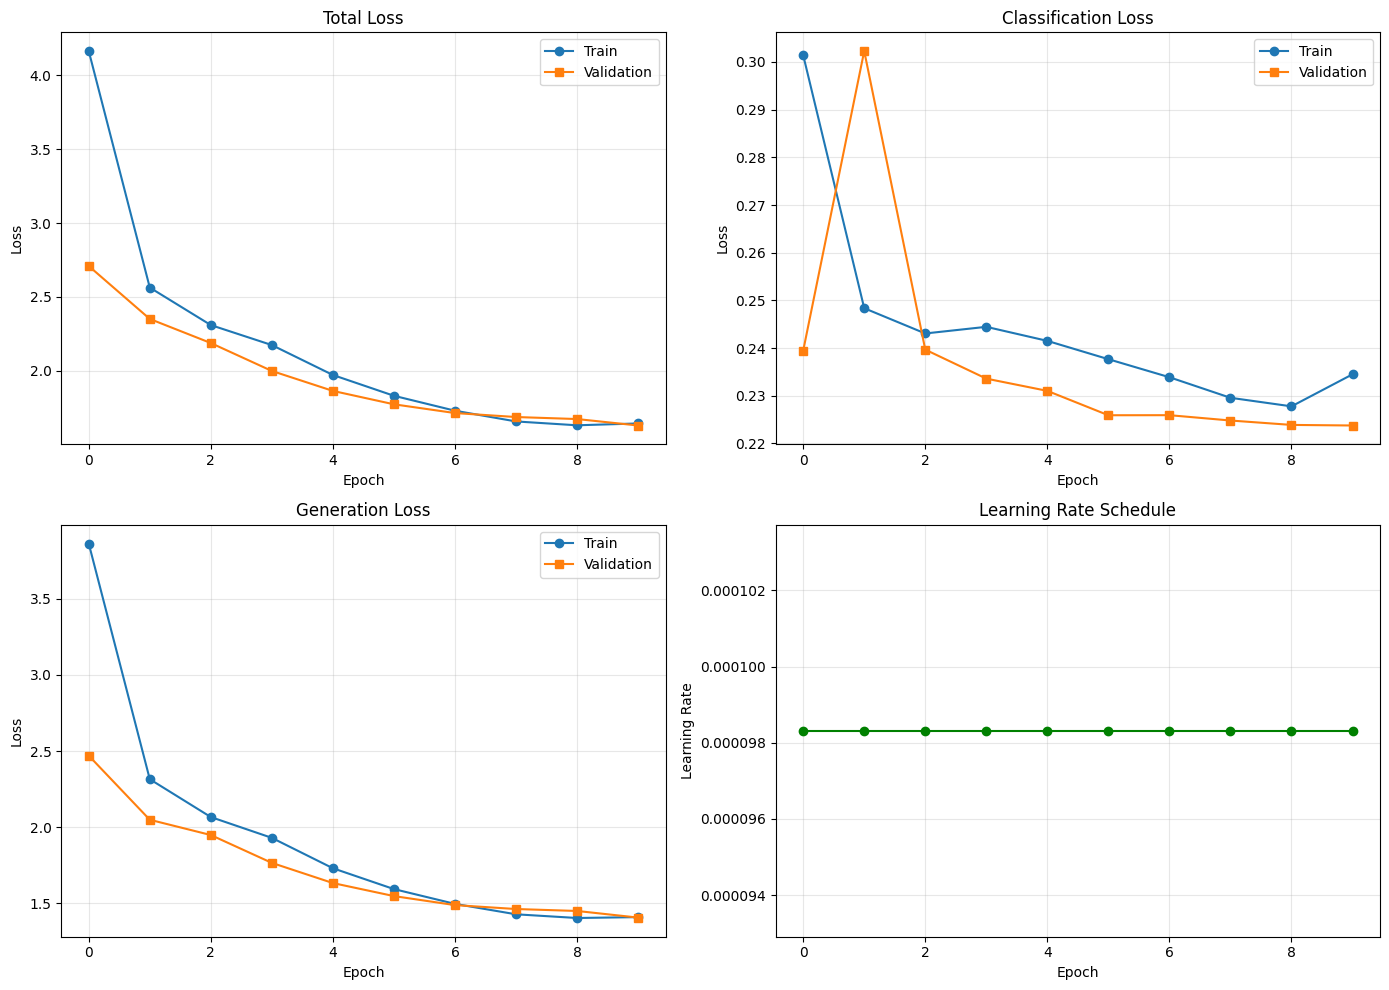

In [32]:
fig,axes=plt.subplots(2,2,figsize=(14,10))

axes[0,0].plot(train_losses,label='Train',marker='o')
axes[0,0].plot(val_losses,label='Validation',marker='s')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].set_title('Total Loss')
axes[0,0].legend()
axes[0,0].grid(True,alpha=0.3)

axes[0,1].plot(train_cls_losses,label='Train',marker='o')
axes[0,1].plot(val_cls_losses,label='Validation',marker='s')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].set_title('Classification Loss')
axes[0,1].legend()
axes[0,1].grid(True,alpha=0.3)

axes[1,0].plot(train_gen_losses,label='Train',marker='o')
axes[1,0].plot(val_gen_losses,label='Validation',marker='s')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Loss')
axes[1,0].set_title('Generation Loss')
axes[1,0].legend()
axes[1,0].grid(True,alpha=0.3)

axes[1,1].plot(range(config.EPOCHS),[optimizer.param_groups[0]['lr'] for _ in range(config.EPOCHS)],marker='o',color='green')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Learning Rate')
axes[1,1].set_title('Learning Rate Schedule')
axes[1,1].grid(True,alpha=0.3)

plt.tight_layout()
plt.show()

## Classification Metrics

Classification Report (Validation Set):
--------------------------------------------------
Pneumonia       - Precision: 0.000, Recall: 0.000, F1: 0.000
Cardiomegaly    - Precision: 0.000, Recall: 0.000, F1: 0.000
Effusion        - Precision: 0.000, Recall: 0.000, F1: 0.000
Atelectasis     - Precision: 0.000, Recall: 0.000, F1: 0.000
Edema           - Precision: 0.000, Recall: 0.000, F1: 0.000


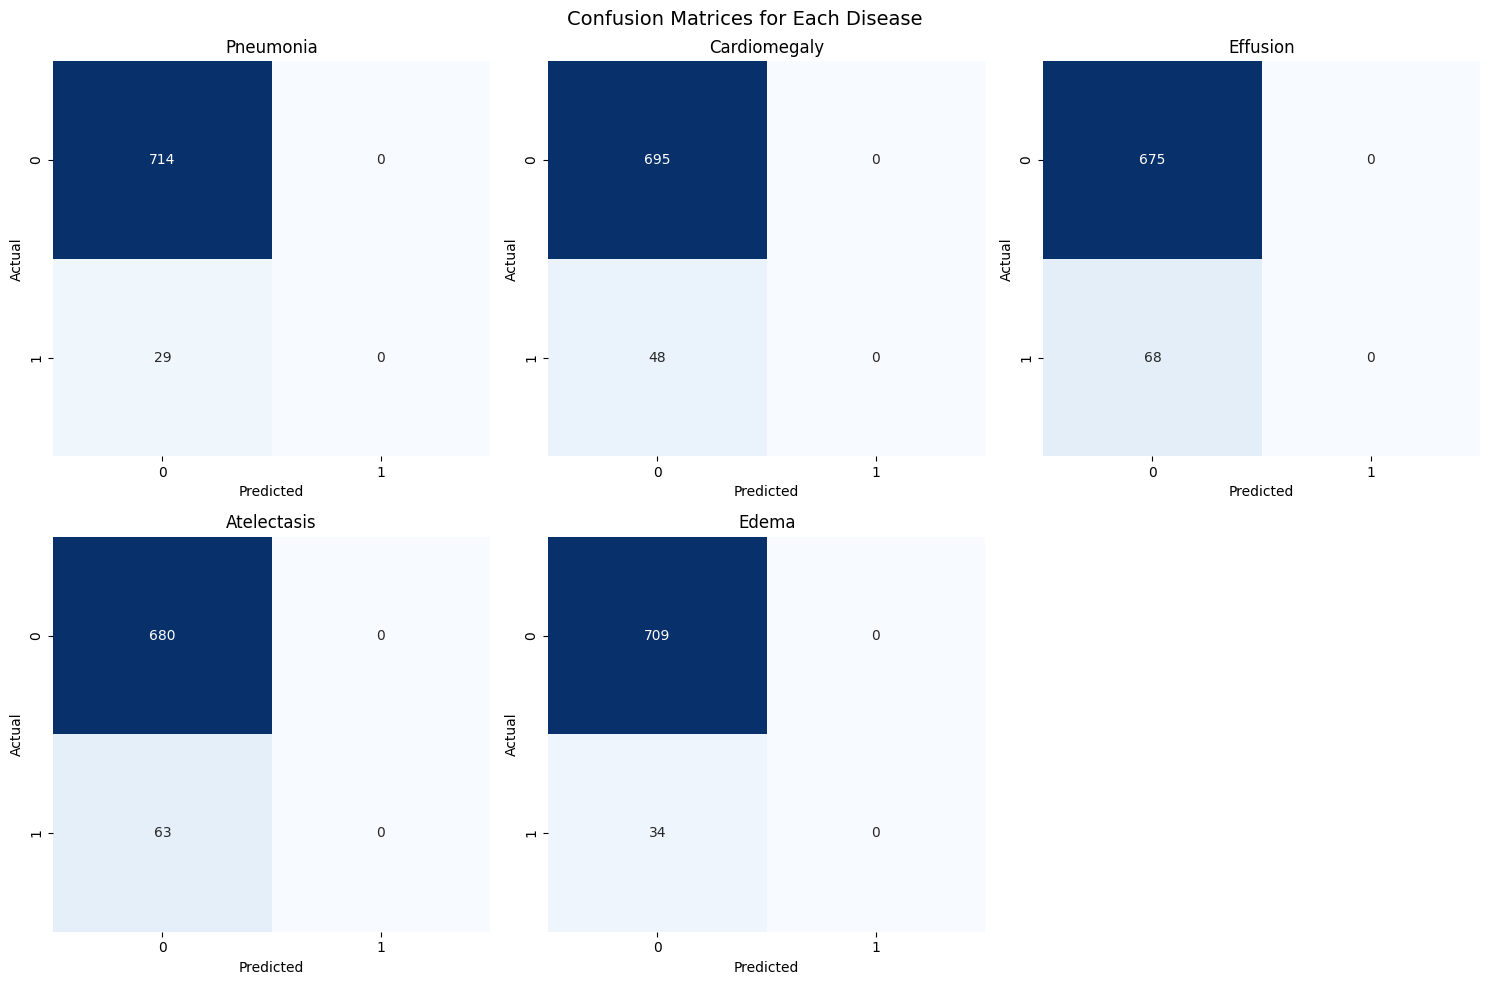

In [35]:
model.eval()
all_preds=[]
all_labels=[]
all_reports=[]
all_images=[]

with torch.no_grad():
    for batch in val_loader:
        images=batch["image"].to(device)
        labels=batch["labels"].cpu().numpy()
        input_ids=batch["input_ids"].to(device)
        attention_mask=batch["attention_mask"].to(device)
        
        cls_out,_=model(images, input_ids, attention_mask)
        preds=torch.sigmoid(cls_out).cpu().numpy()>0.5
        
        all_preds.extend(preds)
        all_labels.extend(labels)
        all_reports.extend(batch["report"])
        all_images.extend(batch["filename"])

all_preds=np.array(all_preds)
all_labels=np.array(all_labels)

print("Classification Report (Validation Set):")
print("-"*50)
for i, disease in enumerate(config.DISEASES):
    from sklearn.metrics import precision_score,recall_score,f1_score
    precision=precision_score(all_labels[:,i],all_preds[:,i],zero_division=0)
    recall=recall_score(all_labels[:,i],all_preds[:,i],zero_division=0)
    f1=f1_score(all_labels[:,i],all_preds[:,i],zero_division=0)
    print(f"{disease.capitalize():15} - Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")

fig,axes=plt.subplots(2,3,figsize=(15,10))
axes=axes.flatten()

for i,disease in enumerate(config.DISEASES):
    cm=confusion_matrix(all_labels[:,i],all_preds[:,i])
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=axes[i],cbar=False)
    axes[i].set_title(f'{disease.capitalize()}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

if len(config.DISEASES)<len(axes):
    axes[-1].axis('off')

plt.suptitle('Confusion Matrices for Each Disease', fontsize=14)
plt.tight_layout()
plt.show()

## Report Generation Function

In [36]:
def generate_report(model,image_path,tokenizer,max_len=100,temperature=1.0):
    model.eval()
    
    transform=val_transform
    try:
        image=Image.open(image_path).convert("RGB")
        image=transform(image).unsqueeze(0).to(device)
    except Exception as e:
        print(f"Error loading image: {e}")
        return ""
    
    with torch.no_grad():
        features=model.encoder(image)
    
    input_ids=torch.tensor([[tokenizer.cls_token_id]]).to(device)
    attention_mask=torch.tensor([[1]]).to(device)
    
    generated_tokens=[]
    
    with torch.no_grad():
        for step in range(max_len):
            outputs=model.report_generator(features,input_ids,attention_mask)
            next_token_logits=outputs[:,-1,:]/temperature
            
            probs=torch.softmax(next_token_logits,dim=-1)
            next_token=torch.multinomial(probs,num_samples=1)
            
            if next_token.item()==tokenizer.sep_token_id:
                break
            
            generated_tokens.append(next_token.item())
            
            input_ids=torch.cat([input_ids,next_token],dim=1)
            attention_mask=torch.cat([attention_mask,torch.ones_like(next_token)],dim=1)
    
    generated_text=tokenizer.decode(generated_tokens,skip_special_tokens=True)
    return generated_text

In [37]:
def generate_report_greedy(model,image_path,tokenizer,max_len=100):
    model.eval()
    
    transform=val_transform
    try:
        image=Image.open(image_path).convert("RGB")
        image=transform(image).unsqueeze(0).to(device)
    except Exception as e:
        print(f"Error loading image: {e}")
        return ""
    
    with torch.no_grad():
        features=model.encoder(image)
    
    input_ids=torch.tensor([[tokenizer.cls_token_id]]).to(device)
    attention_mask=torch.tensor([[1]]).to(device)
    
    generated_tokens=[]
    
    with torch.no_grad():
        for _ in range(max_len):
            outputs=model.report_generator(features,input_ids,attention_mask)
            next_token=outputs[:,-1].argmax(-1).unsqueeze(1)
            
            if next_token.item()==tokenizer.sep_token_id:
                break
            
            generated_tokens.append(next_token.item())
            input_ids=torch.cat([input_ids, next_token], dim=1)
            attention_mask=torch.cat([attention_mask,torch.ones_like(next_token)],dim=1)
    
    generated_text=tokenizer.decode(generated_tokens,skip_special_tokens=True)
    return generated_text

##  Test Report Generation

Testing report generation on validation samples:

--- Sample 1 ---


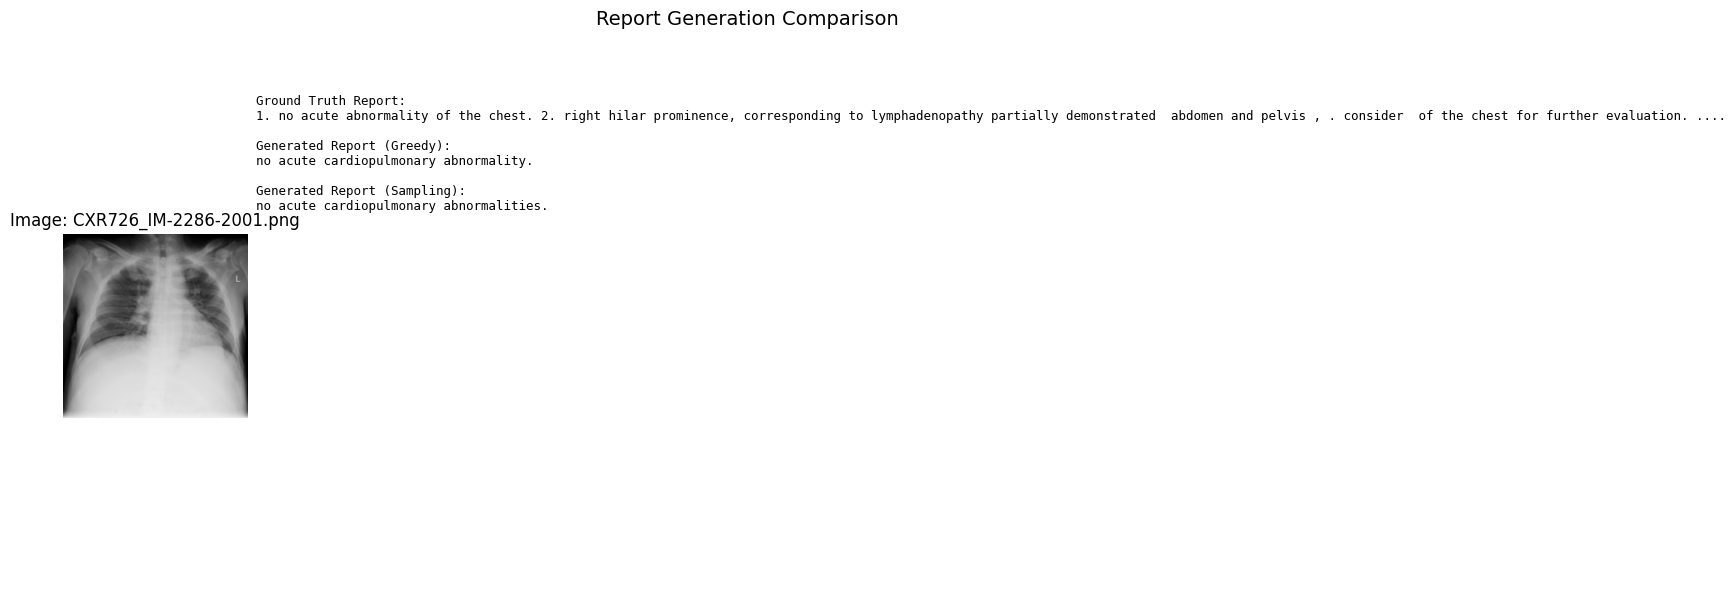


--- Sample 2 ---


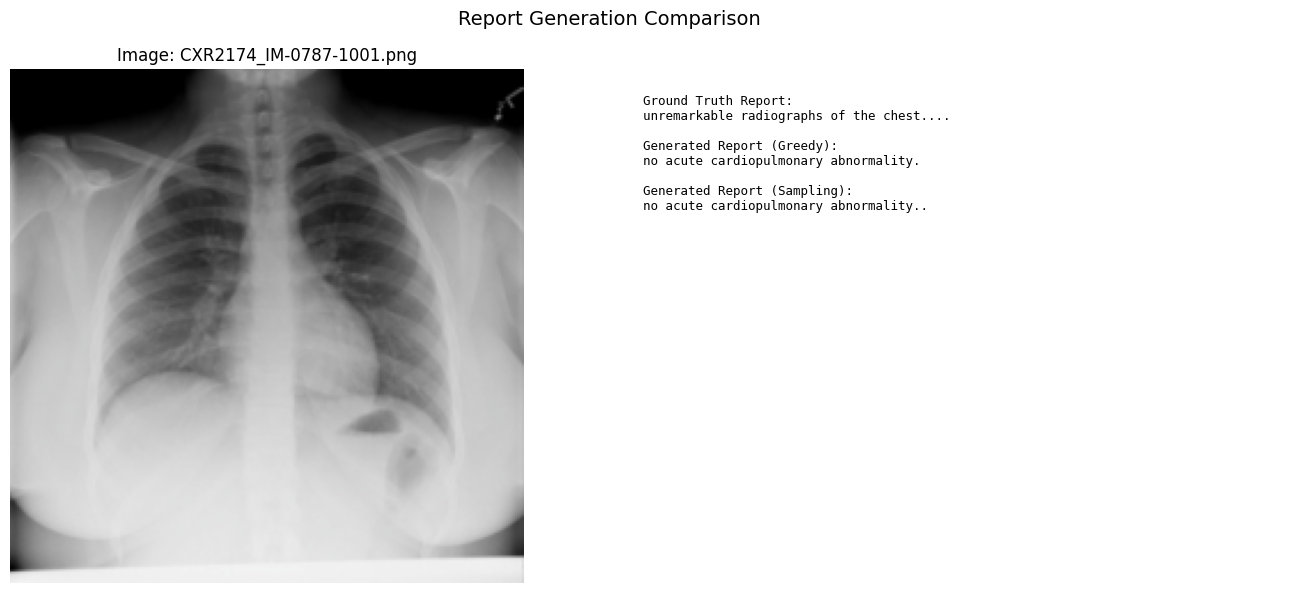


--- Sample 3 ---


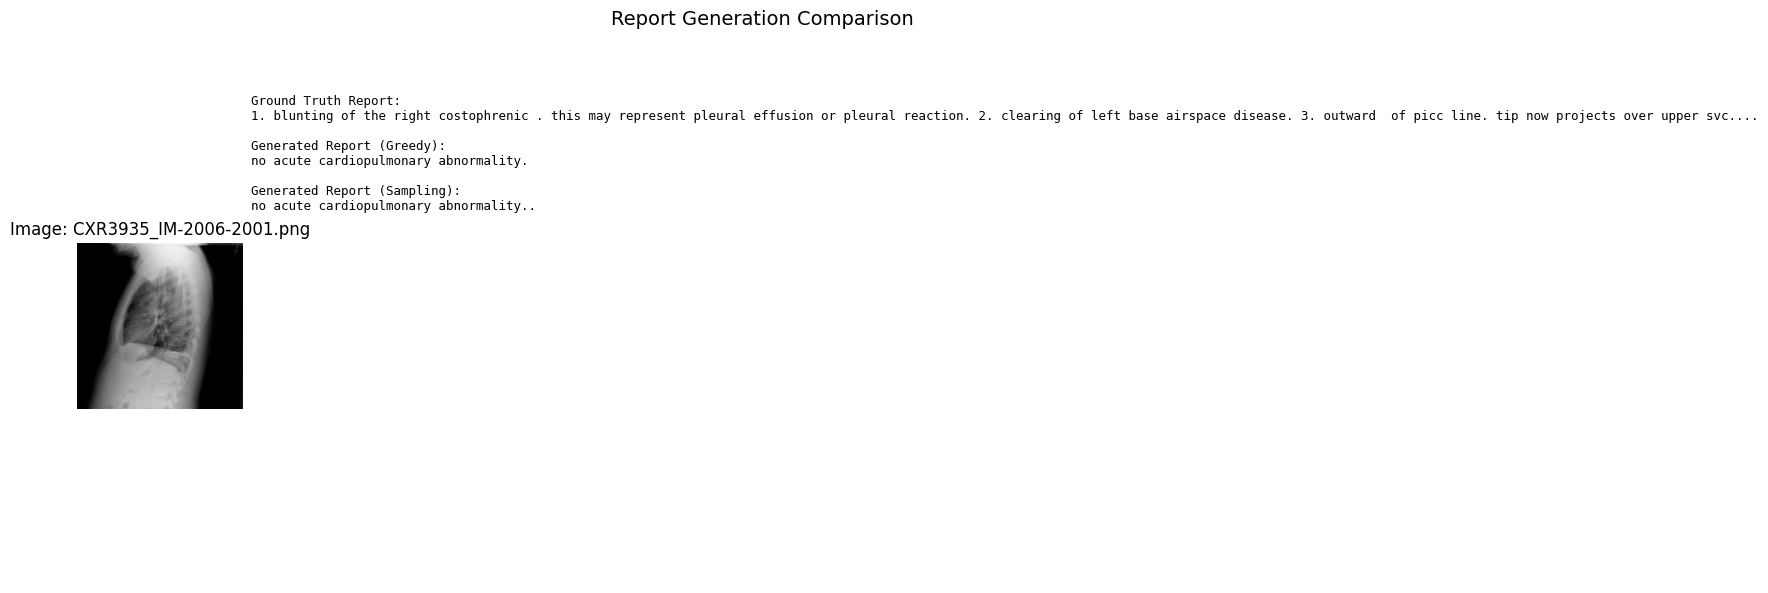


--- Sample 4 ---


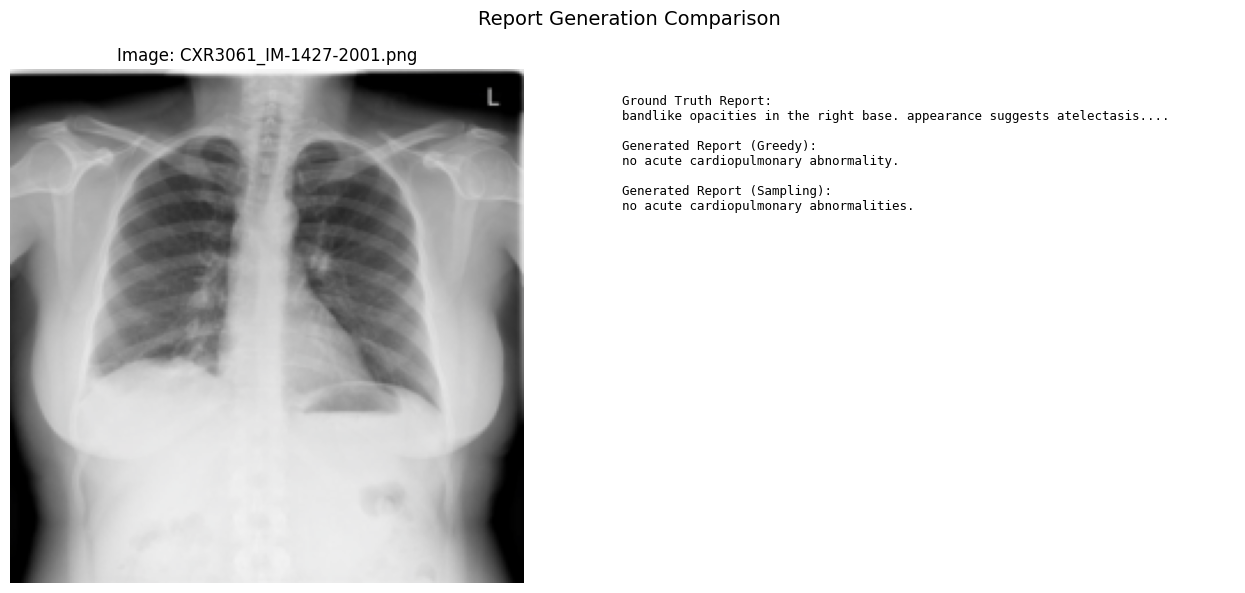


--- Sample 5 ---


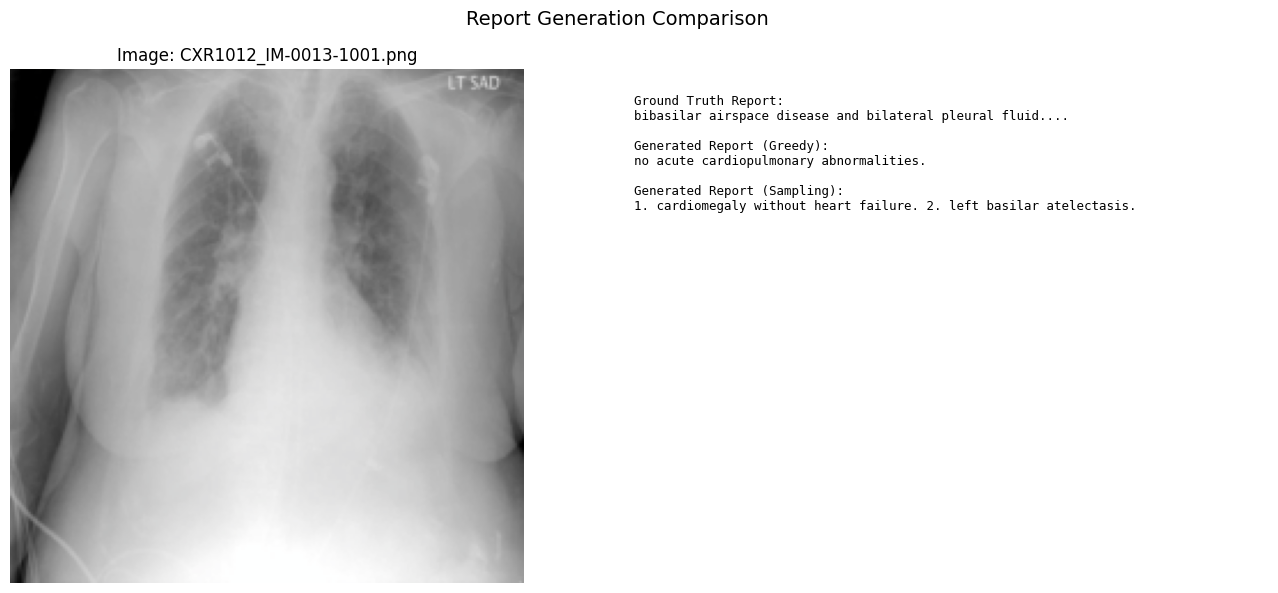

In [38]:
def display_report_generation(idx):
    sample=val_dataset[idx]
    image_path=os.path.join(config.IMAGE_DIR,sample["filename"])
    
    if not os.path.exists(image_path):
        print(f"Image not found: {image_path}")
        return
    
    generated_report_greedy=generate_report_greedy(model,image_path,tokenizer,max_len=100)
    generated_report_sampling=generate_report(model,image_path,tokenizer,max_len=100,temperature=0.7)
    
    fig,axes=plt.subplots(1,2,figsize=(14,6))
    
    img=sample["image"].permute(1,2,0).numpy()
    mean=np.array([0.485,0.456,0.406])
    std=np.array([0.229,0.224,0.225])
    img=img*std+mean
    img=np.clip(img,0,1)
    
    axes[0].imshow(img)
    axes[0].set_title(f"Image: {sample['filename']}")
    axes[0].axis('off')
    
    axes[1].axis('off')
    text_content=f"Ground Truth Report:\n{sample['report'][:300]}...\n\n"
    text_content+=f"Generated Report (Greedy):\n{generated_report_greedy}\n\n"
    text_content+=f"Generated Report (Sampling):\n{generated_report_sampling}"
    
    axes[1].text(0.05,0.95,text_content,transform=axes[1].transAxes,fontsize=9,verticalalignment='top',fontfamily='monospace')
    
    plt.suptitle('Report Generation Comparison', fontsize=14)
    plt.tight_layout()
    plt.show()

print("Testing report generation on validation samples:")
for i in range(min(5, len(val_dataset))):
    print(f"\n--- Sample {i+1} ---")
    display_report_generation(i)